[download this notebook here](https://github.com/HumanCompatibleAI/imitation/blob/master/docs/tutorials/1_train_bc.ipynb)
# Train an Agent using Behavior Cloning

Behavior cloning is the most naive approach to imitation learning. 
We take the transitions of trajectories taken by some expert and use them as training samples to train a new policy.
The method has many drawbacks and often does not work. 
However in this example, where we use an agent for the seals/CartPole-v0 environment, it is feasible.

Note that we use a variant of the CartPole environment from the seals package, which has fixed episode durations. Read more about why we do this [here](https://imitation.readthedocs.io/en/latest/main-concepts/variable_horizon.html).

First we need some kind of expert in CartPole so we can sample some expert trajectories.
For convenience we just download one from the HuggingFace model hub.

If you want to train an expert yourself have a look at the [training documenation](https://rl-baselines3-zoo.readthedocs.io/en/master/guide/train.html#basic-usage) of RL Baselines3 Zoo.

In [1]:
import numpy as np
import gymnasium as gym
from imitation.policies.serialize import load_policy
from imitation.util.util import make_vec_env
from imitation.data.wrappers import RolloutInfoWrapper
from imitation.data.types import TrajectoryWithRew, ObservationSequence, remove_acts
from matplotlib import pyplot as plt
from imitation.data import rollout
from stable_baselines3.common.evaluation import evaluate_policy

from typing import Dict, Optional
from typing import Any
import numpy as np
import gymnasium as gym
import matplotlib
# matplotlib.use("QtAgg", force=True)
import matplotlib.pyplot as plt
# %matplotlib ipympl
# from PyQt6 import QtWidgets
%matplotlib ipympl
from gymnasium.spaces import Box

In [2]:
# env = make_vec_env(
#     "seals:seals/CartPole-v0",
#     rng=np.random.default_rng(),
#     post_wrappers=[
#         lambda env, _: RolloutInfoWrapper(env)
#     ],  # needed for computing rollouts later
# )
# expert = load_policy(
#     "ppo-huggingface",
#     organization="HumanCompatibleAI",
#     env_name="seals/CartPole-v0",
#     venv=env,
# )

In [3]:



class CircleForceEnv(gym.Env):
    """
    2D continuous environment: circle controlled by forces.
    State: [x, y, vx, vy]; Action: [fx, fy].
    Contains both binary RL reward (in step) and a smooth continuous cost.
    Optionally visualizes multiple trajectories, each in its own color.
    Uses PyQt6 for event loop pumping.
    """

    metadata = {"render_modes": ["human"], "render_fps": 30}

    def __init__(
        self,
        width=10.0,
        height=10.0,
        penalty_zones=None,
        goal_region=None,
        mass=1.0,
        dt=0.1,
        energy_coeff=0.01,
        time_penalty=0.1,
        initial_state=None,
        visualize=False,
        render_mode=None,
    ):
        super().__init__()
        # environment parameters
        self.width = width
        self.height = height
        self.mass = mass
        self.dt = dt
        self.energy_coeff = energy_coeff
        self.time_penalty = time_penalty
        self.penalty_zones = penalty_zones or []
        self.goal_region = goal_region

        # initial state handling
        default_state = np.array([1.0, self.height - 1.0, 0.0, 0.0], dtype=np.float32)
        if initial_state is None:
            self.initial_state = default_state
        else:
            self.initial_state = np.array(initial_state, dtype=np.float32)

        # action & observation spaces
        self.action_space = Box(low=-1.0, high=1.0, shape=(2,), dtype=np.float32)
        high = np.array([width, height, np.inf, np.inf], dtype=np.float32)
        self.observation_space = Box(low=-high, high=high, dtype=np.float32)

        # visualization flags and storage
        self.visualize = visualize
        self.render_mode = render_mode
        self._episodes = []  # list of dicts: {'line': Line2D, 'positions': [pts]}

        if self.visualize and self.render_mode in ["human", "episode"]:
            # set up QApplication for PyQt6
            # self._app = QtWidgets.QApplication.instance() or QtWidgets.QApplication(
            #     sys.argv
            # )
            # initialize Matplotlib figure
            # plt.ion()
            self._fig, self._ax = plt.subplots()
            self._ax.set_xlim(0, self.width)
            self._ax.set_ylim(0, self.height)
            self._ax.set_aspect("equal")

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        # initialize to the preset initial state
        self.state = self.initial_state.copy()

        if self.visualize:
            if self.render_mode == "episode" and len(self._episodes) > 0:
                self.render()
            # start a new trajectory: create line and position buffer
            self.plot_color = np.random.rand(
                3,
            )
            (line,) = self._ax.plot([], [], color=self.plot_color)
            ep = {"line": line, "positions": [self.state[:2].copy()]}
            self._episodes.append(ep)

        return self.state.copy(), {}

    def _step(self, action, do_render, append_to_episode):
        # physics update internal method
        pos, vel = self.state[:2], self.state[2:]
        force = np.clip(action, self.action_space.low, self.action_space.high)
        accel = force / self.mass
        new_vel = vel + accel * self.dt
        new_pos = pos + new_vel * self.dt
        self.state = np.concatenate([new_pos, new_vel])

        # reward computation
        r = 0.0
        for center, radius, penalty in self.penalty_zones:
            if np.linalg.norm(new_pos - center) <= radius:
                r -= penalty
        if self.goal_region:
            c, rad, rew = self.goal_region
            if np.linalg.norm(new_pos - c) <= rad:
                r += rew
        r -= self.energy_coeff * np.dot(force, force)
        r -= self.time_penalty

        # termination
        done = False
        if not (0 <= new_pos[0] <= self.width and 0 <= new_pos[1] <= self.height):
            done = True
        if (
            self.goal_region
            and np.linalg.norm(new_pos - self.goal_region[0]) <= self.goal_region[1]
        ):
            done = True

        # update only positions; defer plotting to render()
        if append_to_episode:
            self._episodes[-1]["positions"].append(new_pos.copy())

        if do_render:
            self.render()

        return self.state.copy(), r, done, False, {}

    def step_no_visualize(self, action):
        """Convenience method for step without visualization."""
        # physics update
        return self._step(action, do_render=False, append_to_episode=False)

    def step(self, action):
        return self._step(
            action,
            do_render=self.render_mode == "human",
            append_to_episode=self.visualize,
        )

    def render(self):
        # conforms to Gymnasium API; updates the latest trajectory
        if not (self.visualize and self.render_mode in ["human", "episode"]):
            return None
        ep = self._episodes[-1]
        xs, ys = zip(*ep["positions"])
        ep["line"].set_data(xs, ys)
        self._ax.set_title(f"Episode {len(self._episodes)} Step {len(xs) - 1}")
        self._fig.canvas.draw()
        self._fig.canvas.flush_events()
        plt.pause(1 / self.metadata["render_fps"])
        # process Qt events to keep window responsive
        # self._app.processEvents()

    def close(self):
        if self.visualize and self.render_mode == "human":
            plt.ioff()
            plt.close(self._fig)
            # exit Qt loop if necessary
            # self._app.quit()


In [4]:
gym.register(
    id="custom/CircleForce-v0",
    entry_point=CircleForceEnv,  # This can also be the path to the class, e.g. `observation_matching:ObservationMatchingEnv`
    max_episode_steps=500,
)
# Create a single environment for training an expert with SB3
# env = gym.make("custom/CircleForce-v0")


# Create a vectorized environment for training with `imitation`

# Option A: use the `make_vec_env` helper function - make sure to pass `post_wrappers=[lambda env, _: RolloutInfoWrapper(env)]`
env = make_vec_env(
    "custom/CircleForce-v0",
    rng=np.random.default_rng(),
    n_envs=4,
    post_wrappers=[lambda env, _: RolloutInfoWrapper(env)],
)

Let's quickly check if the expert is any good.
We usually should be able to reach a reward of 500, which is the maximum achievable value.

In [5]:
# from stable_baselines3.common.evaluation import evaluate_policy

# reward, _ = evaluate_policy(expert, env, 10)
# print(reward)

Now we can use the expert to sample some trajectories.
We flatten them right away since we are only interested in the individual transitions for behavior cloning.
`imitation` comes with a number of helper functions that makes collecting those transitions really easy. First we collect 50 episode rollouts, then we flatten them to just the transitions that we need for training.

Note that the rollout function requires a vectorized environment and needs the `RolloutInfoWrapper` around each of the environments. This is why we passed the `post_wrappers` argument to `make_vec_env` above.

In [6]:
t2 = np.load('../data/demonstration_traj/optimized_data.npz')

In [7]:
t2

NpzFile '../data/demonstration_traj/optimized_data.npz' with keys: ctrls, rewards, final_path

In [8]:
print(t2['ctrls'].shape, t2['final_path'].shape, t2['rewards'].shape)

(1, 45, 2) (1, 46, 4) (45,)


In [9]:
traj=TrajectoryWithRew(t2['final_path'][0], t2['ctrls'][0],
                  np.array([{}]*t2['ctrls'].shape[1]), True, t2['rewards'])

TypeError: object of type 'bool' has no len()

In [22]:
roll1 = [traj]
tran1 = rollout.flatten_trajectories(roll1)

In [43]:
roll1[0]

TrajectoryWithRew(obs=array([[ 1.        ,  9.        ,  0.        ,  0.        ],
       [ 1.01      ,  9.01      ,  0.1       ,  0.1       ],
       [ 1.03      ,  9.02634734,  0.2       ,  0.16347339],
       [ 1.06      ,  9.04532404,  0.3       ,  0.18976697],
       [ 1.1       ,  9.0632121 ,  0.4       ,  0.17888062],
       [ 1.15      ,  9.07629355,  0.5       ,  0.1308145 ],
       [ 1.21      ,  9.08085046,  0.6       ,  0.04556909],
       [ 1.28      ,  9.07540737,  0.7       , -0.05443091],
       [ 1.36      ,  9.05996428,  0.8       , -0.15443091],
       [ 1.45      ,  9.03452118,  0.9       , -0.25443091],
       [ 1.55      ,  8.99907809,  1.        , -0.35443091],
       [ 1.66      ,  8.953635  ,  1.1       , -0.45443091],
       [ 1.78      ,  8.89819191,  1.2       , -0.55443091],
       [ 1.91      ,  8.83274882,  1.3       , -0.65443091],
       [ 2.05      ,  8.75730573,  1.4       , -0.75443091],
       [ 2.2       ,  8.67186264,  1.5       , -0.85443091],
  

In [27]:
#np.array([{}]*100)

In [28]:
t2['final_path'].shape

(1, 46, 4)

In [29]:
#np.array([{}]*t2['final_path'].shape[1])

In [31]:
# dir(rollouts[0])

Let's have a quick look at what we just generated using those library functions:

After we collected our transitions, it's time to set up our behavior cloning algorithm.

In [39]:
print([x for x in tran1 if "__" not in x])

[{'obs': array([1., 9., 0., 0.]), 'acts': array([1., 1.]), 'infos': {}, 'next_obs': array([1.01, 9.01, 0.1 , 0.1 ]), 'dones': np.False_}, {'obs': array([1.01, 9.01, 0.1 , 0.1 ]), 'acts': array([1.        , 0.63473388]), 'infos': {}, 'next_obs': array([1.03      , 9.02634734, 0.2       , 0.16347339]), 'dones': np.False_}, {'obs': array([1.03      , 9.02634734, 0.2       , 0.16347339]), 'acts': array([1.        , 0.26293579]), 'infos': {}, 'next_obs': array([1.06      , 9.04532404, 0.3       , 0.18976697]), 'dones': np.False_}, {'obs': array([1.06      , 9.04532404, 0.3       , 0.18976697]), 'acts': array([ 1.        , -0.10886344]), 'infos': {}, 'next_obs': array([1.1       , 9.0632121 , 0.4       , 0.17888062]), 'dones': np.False_}, {'obs': array([1.1       , 9.0632121 , 0.4       , 0.17888062]), 'acts': array([ 1.       , -0.4806612]), 'infos': {}, 'next_obs': array([1.15      , 9.07629355, 0.5       , 0.1308145 ]), 'dones': np.False_}, {'obs': array([1.15      , 9.07629355, 0.5      

In [41]:
tran1[0]

{'obs': array([1., 9., 0., 0.]),
 'acts': array([1., 1.]),
 'infos': {},
 'next_obs': array([1.01, 9.01, 0.1 , 0.1 ]),
 'dones': np.False_}

In [66]:
from imitation.algorithms import bc
rng = np.random.default_rng()

bc_trainer = bc.BC(
    observation_space=env.observation_space,
    action_space=env.action_space,
    demonstrations=tran1,
    rng=rng,
)

In [65]:
tran1.dones.shape

(45,)

As you can see the untrained policy only gets poor rewards:

In [34]:
reward_before_training, _ = evaluate_policy(bc_trainer.policy, env, 10)
print(f"Reward before training: {reward_before_training}")

Reward before training: -50.00022


After training, we can match the rewards of the expert (500):

In [89]:
bc_trainer.train(n_epochs=5000)
reward_after_training, out2 = evaluate_policy(bc_trainer.policy, env, 10)
print(f"Reward after training: {reward_after_training}")

0batch [00:00, ?batch/s]

---------------------------------
| batch_size        | 32        |
| bc/               |           |
|    batch          | 0         |
|    ent_loss       | -0.000586 |
|    entropy        | 0.586     |
|    epoch          | 0         |
|    l2_loss        | 0         |
|    l2_norm        | 127       |
|    loss           | -0.4      |
|    neglogp        | -0.4      |
|    prob_true_act  | 1.49      |
|    samples_so_far | 32        |
---------------------------------



Epoch 0 of 5000         
Epoch 1 of 5000
Epoch 2 of 5000
Epoch 3 of 5000
Epoch 4 of 5000
Epoch 5 of 5000
Epoch 6 of 5000
Epoch 7 of 5000
Epoch 8 of 5000
Epoch 9 of 5000
Epoch 10 of 5000
Epoch 11 of 5000
Epoch 12 of 5000
Epoch 13 of 5000
Epoch 14 of 5000
Epoch 15 of 5000
Epoch 16 of 5000
19batch [00:00, 188.55batch/s]
Epoch 18 of 5000              
Epoch 19 of 5000
Epoch 20 of 5000
Epoch 21 of 5000
Epoch 22 of 5000
Epoch 23 of 5000
Epoch 24 of 5000
Epoch 25 of 5000
Epoch 26 of 5000
Epoch 27 of 5000
Epoch 28 of 5000
Epoch 29 of 5000
Epoch 30 of 5000
Epoch 31 of 5000
Epoch 32 of 5000
Epoch 33 of 5000
Epoch 34 of 5000
Epoch 35 of 5000
38batch [00:00, 184.77batch/s]
Epoch 37 of 5000              
Epoch 38 of 5000
Epoch 39 of 5000
Epoch 40 of 5000
Epoch 41 of 5000
Epoch 42 of 5000
Epoch 43 of 5000
Epoch 44 of 5000
Epoch 45 of 5000
Epoch 46 of 5000
Epoch 47 of 5000
Epoch 48 of 5000
Epoch 49 of 5000
Epoch 50 of 5000
Epoch 51 of 5000
Epoch 52 of 5000
Epoch 53 of 5000
Epoch 54 of 5000
57batch [

--------------------------------
| batch_size        | 32       |
| bc/               |          |
|    batch          | 500      |
|    ent_loss       | 0.000467 |
|    entropy        | -0.467   |
|    epoch          | 500      |
|    l2_loss        | 0        |
|    l2_norm        | 149      |
|    loss           | -1.46    |
|    neglogp        | -1.46    |
|    prob_true_act  | 4.32     |
|    samples_so_far | 16032    |
--------------------------------



Epoch 500 of 5000
Epoch 501 of 5000
Epoch 502 of 5000
Epoch 503 of 5000
Epoch 504 of 5000
Epoch 505 of 5000
Epoch 506 of 5000
Epoch 507 of 5000
Epoch 508 of 5000
Epoch 509 of 5000
Epoch 510 of 5000
Epoch 511 of 5000
Epoch 512 of 5000
Epoch 513 of 5000
Epoch 514 of 5000
Epoch 515 of 5000
Epoch 516 of 5000
519batch [00:02, 191.57batch/s]
Epoch 518 of 5000              
Epoch 519 of 5000
Epoch 520 of 5000
Epoch 521 of 5000
Epoch 522 of 5000
Epoch 523 of 5000
Epoch 524 of 5000
Epoch 525 of 5000
Epoch 526 of 5000
Epoch 527 of 5000
Epoch 528 of 5000
Epoch 529 of 5000
Epoch 530 of 5000
Epoch 531 of 5000
Epoch 532 of 5000
Epoch 533 of 5000
Epoch 534 of 5000
Epoch 535 of 5000
Epoch 536 of 5000
539batch [00:02, 189.37batch/s]
Epoch 538 of 5000              
Epoch 539 of 5000
Epoch 540 of 5000
Epoch 541 of 5000
Epoch 542 of 5000
Epoch 543 of 5000
Epoch 544 of 5000
Epoch 545 of 5000
Epoch 546 of 5000
Epoch 547 of 5000
Epoch 548 of 5000
Epoch 549 of 5000
Epoch 550 of 5000
Epoch 551 of 5000
Epoch 5

...

--------------------------------
| batch_size        | 32       |
| bc/               |          |
|    batch          | 4000     |
|    ent_loss       | 0.00671  |
|    entropy        | -6.71    |
|    epoch          | 4000     |
|    l2_loss        | 0        |
|    l2_norm        | 202      |
|    loss           | -6.7     |
|    neglogp        | -6.7     |
|    prob_true_act  | 1.27e+03 |
|    samples_so_far | 128032   |
--------------------------------



Epoch 4000 of 5000
Epoch 4001 of 5000
Epoch 4002 of 5000
Epoch 4003 of 5000
Epoch 4004 of 5000
Epoch 4005 of 5000
4008batch [00:20, 201.55batch/s]
Epoch 4007 of 5000              
Epoch 4008 of 5000
Epoch 4009 of 5000
Epoch 4010 of 5000
Epoch 4011 of 5000
Epoch 4012 of 5000
Epoch 4013 of 5000
Epoch 4014 of 5000
Epoch 4015 of 5000
Epoch 4016 of 5000
Epoch 4017 of 5000
Epoch 4018 of 5000
Epoch 4019 of 5000
Epoch 4020 of 5000
Epoch 4021 of 5000
Epoch 4022 of 5000
Epoch 4023 of 5000
Epoch 4024 of 5000
Epoch 4025 of 5000
Epoch 4026 of 5000
Epoch 4027 of 5000
4030batch [00:20, 204.84batch/s]
Epoch 4029 of 5000              
Epoch 4030 of 5000
Epoch 4031 of 5000
Epoch 4032 of 5000
Epoch 4033 of 5000
Epoch 4034 of 5000
Epoch 4035 of 5000
Epoch 4036 of 5000
Epoch 4037 of 5000
Epoch 4038 of 5000
Epoch 4039 of 5000
Epoch 4040 of 5000
Epoch 4041 of 5000
Epoch 4042 of 5000
Epoch 4043 of 5000
Epoch 4044 of 5000
Epoch 4045 of 5000
Epoch 4046 of 5000
Epoch 4047 of 5000
Epoch 4048 of 5000
4051batch [0

--------------------------------
| batch_size        | 32       |
| bc/               |          |
|    batch          | 4500     |
|    ent_loss       | 0.00729  |
|    entropy        | -7.29    |
|    epoch          | 4500     |
|    l2_loss        | 0        |
|    l2_norm        | 207      |
|    loss           | -7.83    |
|    neglogp        | -7.84    |
|    prob_true_act  | 2.91e+03 |
|    samples_so_far | 144032   |
--------------------------------



Epoch 4500 of 5000
Epoch 4501 of 5000
Epoch 4502 of 5000
Epoch 4503 of 5000
Epoch 4504 of 5000
Epoch 4505 of 5000
Epoch 4506 of 5000
Epoch 4507 of 5000
Epoch 4508 of 5000
Epoch 4509 of 5000
Epoch 4510 of 5000
Epoch 4511 of 5000
Epoch 4512 of 5000
Epoch 4513 of 5000
Epoch 4514 of 5000
4517batch [00:22, 210.85batch/s]
Epoch 4516 of 5000              
Epoch 4517 of 5000
Epoch 4518 of 5000
Epoch 4519 of 5000
Epoch 4520 of 5000
Epoch 4521 of 5000
Epoch 4522 of 5000
Epoch 4523 of 5000
Epoch 4524 of 5000
Epoch 4525 of 5000
Epoch 4526 of 5000
Epoch 4527 of 5000
Epoch 4528 of 5000
Epoch 4529 of 5000
Epoch 4530 of 5000
Epoch 4531 of 5000
Epoch 4532 of 5000
Epoch 4533 of 5000
Epoch 4534 of 5000
Epoch 4535 of 5000
Epoch 4536 of 5000
4539batch [00:23, 210.35batch/s]
Epoch 4538 of 5000              
Epoch 4539 of 5000
Epoch 4540 of 5000
Epoch 4541 of 5000
Epoch 4542 of 5000
Epoch 4543 of 5000
Epoch 4544 of 5000
Epoch 4545 of 5000
Epoch 4546 of 5000
Epoch 4547 of 5000
Epoch 4548 of 5000
Epoch 4549 o

Reward after training: -6.188551000000001


In [93]:
rollouts = rollout.rollout(
    bc_trainer.policy,
    env,
    rollout.make_sample_until(min_timesteps=20, min_episodes=2),
    rng=rng,
)

In [94]:
rollouts[0].obs.shape

(53, 4)

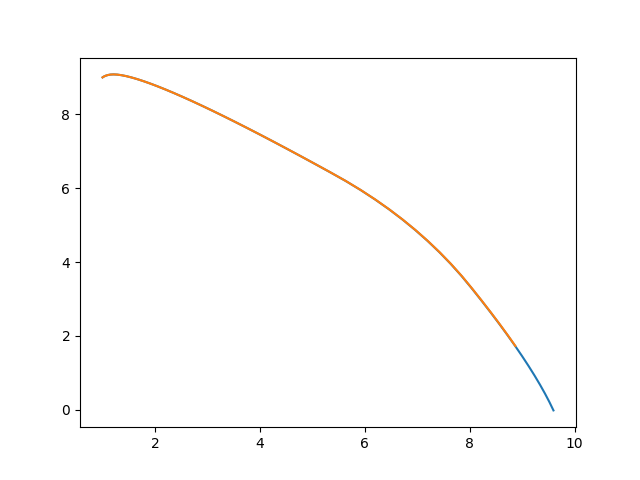

In [95]:
obs0 = rollouts[1].obs
fig, ax = plt.subplots()
ax.plot(obs0[:,0], obs0[:,1])
ax.plot(traj.obs[:,0], traj.obs[:,1])

In [54]:
print(obs0.shape, traj.obs.shape)

(53, 4) (46, 4)


In [53]:
bc_trainer.policy

FeedForward32Policy(
  (features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (pi_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (vf_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (mlp_extractor): MlpExtractor(
    (policy_net): Sequential(
      (0): Linear(in_features=4, out_features=32, bias=True)
      (1): Tanh()
      (2): Linear(in_features=32, out_features=32, bias=True)
      (3): Tanh()
    )
    (value_net): Sequential(
      (0): Linear(in_features=4, out_features=32, bias=True)
      (1): Tanh()
      (2): Linear(in_features=32, out_features=32, bias=True)
      (3): Tanh()
    )
  )
  (action_net): Linear(in_features=32, out_features=2, bias=True)
  (value_net): Linear(in_features=32, out_features=1, bias=True)
)